# 实践项目1：猫狗分类

## 小组人员  
## 杨鹏坤016423120  
## 陈炳行016423112


### 我们组选用的是Pytorch CPU版来进行猫狗分类

### 一、实践时遇到的问题

#### 1、在安装torch CPU版的时候遇见冲突问题然后在CSDN上找相兼容的版本

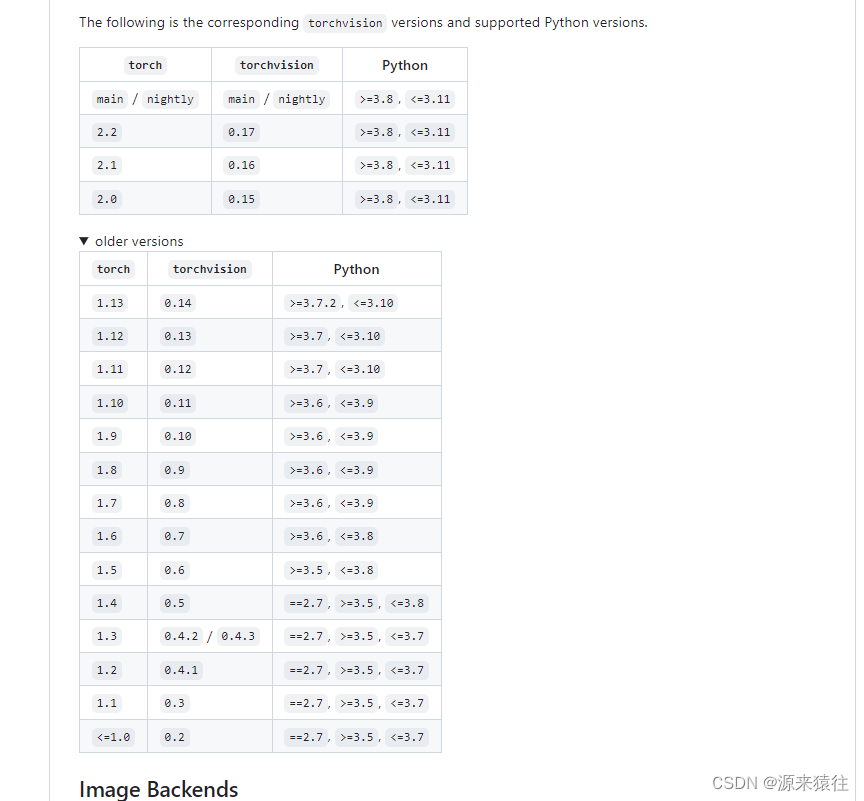

#### 2、数据集太大,没有进行手动解压数据集而是选择使用代码进行解压

#### 3、在进行代码运行时需要导人config文件格式是ipynb文件但是在这里面不能直接进行导入，我们选择使用jupytext库

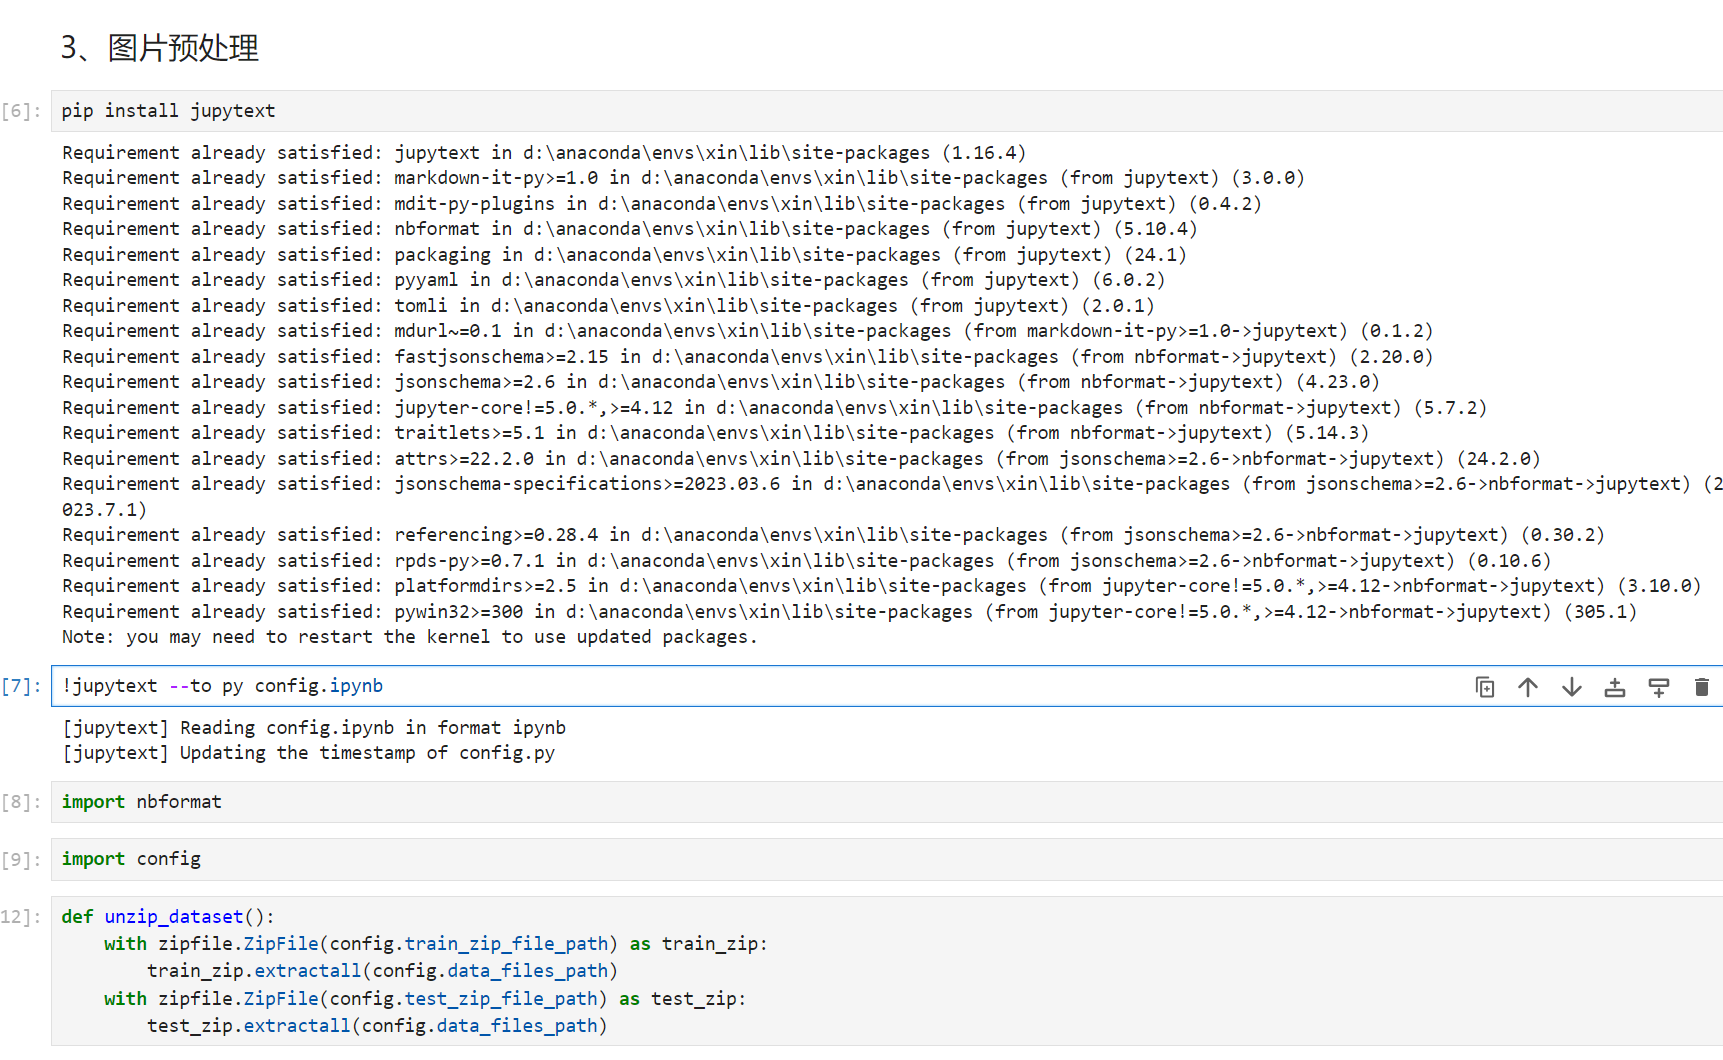

#### 4、需要导入四维数据，然而被导入的数据是三维，我们选择使用reshape将三维数据转换成四维数据

### 二、实践环节

#### 1、数据解压

In [ ]:
# 解压训练集数据集的压缩包
import zipfile

In [ ]:
with zipfile.ZipFile('train.zip') as train_zip:
    train_zip.extractall('')

# 解压测试集数据集的压缩包
with zipfile.ZipFile('test.zip') as test_zip:
    test_zip.extractall('')

In [ ]:
# 把猫狗图片进行分类
import glob
import os #提供一个路径的链接，拼接路径

# 读取数据集，返回文件路径的列表
train_files_list = glob.glob(os.path.join('train', '*.jpg')) # 读取文件,匹配文件名
print(os.path.join('train', '*.jpg'))
print(len(train_files_list))
print(train_files_list[0:10])

test_files_list = glob.glob(os.path.join('test', '*.jpg')) # 读取文件,匹配文件名
print(os.path.join('test', '*.jpg'))
print(len(test_files_list))  # 测试的文件有12500张图片
print(test_files_list[0:10])

#### 2、分析图片数据

#### 1、看单张图片

In [ ]:
# 看单张图片
import matplotlib.pyplot as plt
import random as rand
from PIL import Image

# 随机生成一个index
idx = rand.randint(0, len(train_files_list)-1)
# 读取图片文件
img =  Image.open(train_files_list[idx])
# 显示图片
plt.imshow(img)
plt.axis('off') # 关闭坐标轴
plt.title(train_files_list[idx])
plt.show()

#### 2、看多张图片

In [ ]:
import matplotlib.pyplot as plt
import random as rand
from PIL import Image

rows, cols = 3, 3
idx_list = []
idx = 1
figure = plt.figure(figsize=(8,8))
while len(idx_list) < 9:
    rand_idx = rand.randint(0, len(train_files_list)-1)
    if idx not in idx_list:
        img = Image.open(train_files_list[idx])
        figure.add_subplot(rows, cols, idx)
        plt.imshow(img)
        plt.axis('off') # 关闭坐标轴
        plt.title(train_files_list[idx])
        idx_list.append(idx)
        idx += 1
plt.show()

#### 通过多张图片可以看出，它们的尺寸大小是不都是相同的

### 3、图片预处理

In [ ]:
# 安装这个库是为从工作路径导入另一个ipynb文件
# 因为在这个地方不能直接导入ipynb文件

# 通过命令pip install jupywext安装库然后再进行导入这个库
import jupytext

In [ ]:
!jupytext --to py config.ipynb

In [ ]:
import nbformat

In [ ]:
# 这里的config就是刚刚为了导入的ipynb文件
import config

In [ ]:
def unzip_dataset():
    with zipfile.ZipFile(config.train_zip_file_path) as train_zip:
        train_zip.extractall(config.data_files_path)
    with zipfile.ZipFile(config.test_zip_file_path) as test_zip:
        test_zip.extractall(config.data_files_path)

In [ ]:
def load_dataset():
    train_files_list = glob.glob(os.path.join(config.train_images_files_path, '*.jpg'))
    test_files_list = glob.glob(os.path.join(config.test_images_files_path, '*.jpg'))
    return train_files_list, test_files_list

In [ ]:
if __name__ == '__main__':
    train_files_list, test_files_list = load_dataset()
    img_path = train_files_list[1]
    print(img_path.split('\\'))
    print(img_path.split('\\')[1].split('.')[0])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# 封装数据集
class DogsVsCatsDatasets(Dataset):
    def __init__ (self, image_files_list, is_train=False, transform=None):
        super().__init__()
        self.image_files_list = image_files_list
        self.size = len(image_files_list)
        self.is_train = is_train
        self.transform = transform

    def __len__(self):
        return self.size
    
    def __getitem__(self, item):
        img_path = self.image_files_list[item]
        img = Image.open(img_path)
        if self.transform:
            img = self.transform(img)
        if self.is_train:
            label = img_path.split('\\')[1].split('.')[0] # 提取文件是dog还是cat
            label  = 1 if label == 'dog' else 0           # dog = 1, cat = 0
            return img, label
        else:
            return img
        

In [ ]:

from PIL import Image
from torchvision import transforms


In [ ]:
# 把照片不同尺寸转换成相同尺寸也就是224的尺寸
if __name__ == '__main__':
    transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(), # 对照片进行随机翻转是样本量增大
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    
    train_files_list, test_files_list = load_dataset()
    img = Image.open(train_files_list[0])
    img = transforms(img)
    print(img)

In [ ]:
print(img.shape)     # 卷积神经网络三个特征,224是照片大小为以后训练网络使用

### 4、构建模型

In [ ]:
import torch.nn as nn
import torch

In [ ]:
device ='cuda' if torch.cuda.is_available() else 'cpu'
print(f'使用{device}设备')

In [ ]:
import torch
import torch.nn as nn

#构建卷积层
class DogsVsCatsModel(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device = device
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),  # 修改激活函数名称
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),           
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3),  # 修改为小写的 conv2d 为 Conv2d
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3),
            nn.BatchNorm2d(256),  # 去除多余的空格
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 修改为大写的 MaxPool2d
            nn.Conv2d(256, 512, 3),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 * 5 * 5, 2048),
            nn.ReLU(),
            nn.Dropout(0.5),     # 在一定程度上可以减少计算量
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2),
            nn.Sigmoid(),
        )
    def forward(self, x):
        x = x.to(self.device)
        x = self.conv_layers(x)
        x = x.view(-1, 512 * 5 * 5)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DogsVsCatsModel(device).to(device)
output = model(torch.reshape(img, [1, 3, 224, 224]))
print('原始的形状', img.shape)
print('经过网络之后的输出', output)       

### 5、模型训练

In [ ]:
import torch.optim as optim

In [ ]:

# 创建数据集
train_data_files_list, test_data_files_list = load_dataset()
train_data = DogsVsCatsDatasets(train_data_files_list, is_train=True, transform=transforms)
test_data = DogsVsCatsDatasets(test_data_files_list, is_train=False, transform=transforms)
# 创建dataloaer
train_dataloader = DataLoader(train_data, batch_size=config.minibatch, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=config.minibatch, shuffle=False)
# 创建模型
model = DogsVsCatsModel(device).to(device)
# 定义代价函数和优化器
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
# 正式开始训练
print(f'\nepochs:{config.epochs} learning rate:{config.learning_rate} Using CrossEntropyLoss And Adam optimizer')
for epoch in range(config.epochs):
    # 正确判断的数目
    correct_num = 0
    for batch_idx, data in enumerate(train_dataloader):
        # 获取图片数据和标签数据
        Xs, labels = data
        #把标签放到device上面
        labels = labels.to(device)
        # optimizer的初始化
        optimizer.zero_grad()
        # 前向传播
        output = model(Xs)
        # 生成所需要的输出
        y = torch.zeros(config.minibatch, 2)
        for j in range(config.minibatch):
            y[j][labels[j]] = 1.
        y = y.to(device)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        predict = torch.max(output, 1)[1]
        correct_num += (predict == labels).sum()

        if batch_idx % 10 == 0:
            print(f'epoch:{epoch} batch index:{batch_idx} loss:{loss.item()} correction:{correct_num / (config.minibatch * (batch_idx + 1)) * 100}%')
    torch.save(model.state_dict(), 'model/model1.pth')